# AE signed-PV alignment versus shelf constraint

## Competing explanations

The corrected hypothesis is that AEs align with signed $\nabla PV$, whereas CEs oppose it. An AE distribution close to random on the shelf does not by itself demonstrate cancellation.

1. **PV preference only:** AE alignment remains detectable after controlling for gradient magnitude and environment.
2. **Shelf constraint:** AE alignment weakens specifically near the shelf/land boundary, while a second observable—tilt magnitude, along-shelf redirection, or propagation—also changes.

This notebook separates PV-gradient strength, shelf proximity and within-eddy change. It should be run after regenerating the corrected gradients.


In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import distance_transform_edt
HERE=Path.cwd().resolve()
ANALYSIS_ROOT=next((p for p in (HERE,*HERE.parents) if (p/'seacofs_tilt_tools.py').exists()),None)
if ANALYSIS_ROOT is None: raise FileNotFoundError('Run below seacofs_eddy_tilt_analysis.')
for path in (ANALYSIS_ROOT,ANALYSIS_ROOT/'case_studies'):
 if str(path) not in sys.path: sys.path.insert(0,str(path))
import seacofs_tilt_tools as tilt
from case_study_tools import PVAlignmentConfig,add_pv_alignment_diagnostics
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns',80)


## 1. Rebuild gradients and audit the convention

Southern Hemisphere planetary beta must be positive and its signed gradient should point approximately northward. Stop here if these checks fail.


In [2]:
DOMINANCE_FACTOR=2.0
MIN_TILT_km=5.0
ALIGNMENT_DEG=45.0
paths=tilt.Paths()
grid=tilt.load_grid(paths.grid,paths.z_r)
df,_=tilt.load_tilt_tables(paths)
df=tilt.add_region_labels(df,grid)
df=tilt.add_pv_gradient_terms(df,grid,core_mean=True)
d=add_pv_alignment_diagnostics(df,PVAlignmentConfig(
 dominance_factor=DOMINANCE_FACTOR,min_tilt_distance_km=MIN_TILT_km))
d=d[d.direction_valid].replace([np.inf,-np.inf],np.nan).copy()
print('Planetary beta range:',d.beta.min(),d.beta.max())
print('Median planetary-gradient bearing:',d.PV_grad_plan_theta.median())
assert d.beta.dropna().median()>0,'Expected positive beta in the Southern Hemisphere.'


Planetary beta range: 1.75564771613126e-11 2.0786869653181334e-11
Median planetary-gradient bearing: 0.0


## 2. Define the response and independent shelf proxies

For AEs, zero preference error means alignment. For CEs, zero means opposition. Coast distance is only a geometric proxy; it is kept separate from depth, slope and the topographic/planetary PV ratio.


In [3]:
d['raw_mismatch']=d.dtheta_PV_grad
d['preference_error']=np.where(d.Cyc.eq('AE'),d.raw_mismatch,180.0-d.raw_mismatch)
d['predicted_30']=d.preference_error<=ALIGNMENT_DEG
d['response_cosine']=np.cos(np.deg2rad(d.raw_mismatch))
d['slope_mag']=np.hypot(d.dhdx,d.dhdy)
d['log_topo_plan']=d.topo_plan_ratio
dx=float(np.nanmedian(np.abs(np.diff(grid.X_grid,axis=0))))
dy=float(np.nanmedian(np.abs(np.diff(grid.Y_grid,axis=1))))
coast_distance=distance_transform_edt(grid.mask_rho.astype(bool),sampling=(dx,dy))
d['coast_distance_km']=coast_distance[d.ic.astype(int),d.jc.astype(int)]
display(d.groupby('Cyc').agg(observations=('Eddy','size'),eddies=('Eddy','nunique'),
 median_raw_mismatch=('raw_mismatch','median'),
 median_preference_error=('preference_error','median'),
 predicted_fraction=('predicted_30','mean')).round(3))


,observations,eddies,median_raw_mismatch,median_preference_error,predicted_fraction
Cyc,,,,,
AE,49268,1421,86.895,86.895,0.264
CE,46397,1530,114.781,65.219,0.367


## 3. Full planetary-to-topographic transition

Do not preselect topographic cases. The AE constraint hypothesis predicts alignment in the planetary regime followed by reduced coherence as shelf contact increases. The CE hypothesis predicts increasing opposition to the rotating/topographic signed gradient.


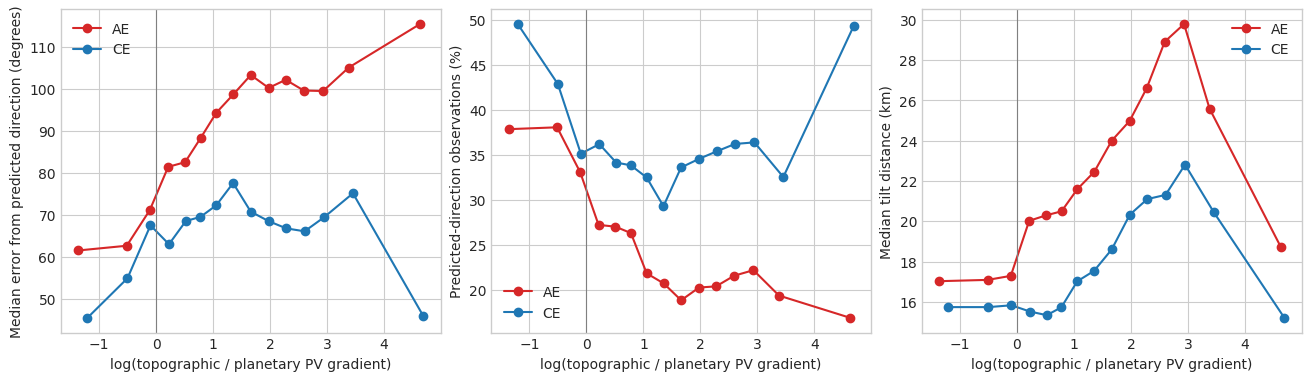

In [4]:
use=d.dropna(subset=['log_topo_plan','preference_error','coast_distance_km']).copy()
use['regime_bin']=pd.qcut(use.log_topo_plan,15,duplicates='drop')
stats=(use.groupby(['Cyc','regime_bin'],observed=True)
 .agg(x=('log_topo_plan','median'),error=('preference_error','median'),
 p_predicted=('predicted_30','mean'),distance=('coast_distance_km','median'),
 tilt=('TiltDis','median'),eddies=('Eddy','nunique')).reset_index())
fig,axs=plt.subplots(1,3,figsize=(13,3.7),constrained_layout=True)
for cyc,color in [('AE','tab:red'),('CE','tab:blue')]:
 part=stats[stats.Cyc==cyc]
 axs[0].plot(part.x,part.error,'-o',color=color,label=cyc)
 axs[1].plot(part.x,100*part.p_predicted,'-o',color=color,label=cyc)
 axs[2].plot(part.x,part.tilt,'-o',color=color,label=cyc)
axs[0].set_ylabel('Median error from predicted direction (degrees)')
axs[1].set_ylabel('Predicted-direction observations (%)')
axs[2].set_ylabel('Median tilt distance (km)')
for ax in axs: ax.axvline(0,color='0.5',lw=.8);ax.set_xlabel('log(topographic / planetary PV gradient)');ax.legend(frameon=False)


## 4. Does proximity matter after matching PV-gradient regime?

Within narrow topographic/planetary-ratio bins, compare near and far AEs. A shelf constraint requires proximity to worsen AE alignment beyond the effect of gradient strength. Repeat several distance cutoffs rather than selecting the best-looking one.


,cutoff_km,ratio_bin,near,preference_error,p_predicted,tilt_km,observations,eddies
0,25,"(-5.5360000000000005, -0.828]",False,61.114138,0.379947,17.013363,4927,535
1,25,"(-0.828, -0.279]",False,63.019382,0.379541,17.044240,4927,659
2,25,"(-0.279, 0.112]",False,71.721150,0.322915,17.599094,4927,749
3,25,"(0.112, 0.516]",False,82.938672,0.268372,19.973816,4926,811
4,25,"(0.516, 0.926]",False,85.631487,0.265679,20.628518,4927,842
5,25,"(0.926, 1.335]",False,96.440839,0.214779,21.689038,4926,841
7,25,"(1.335, 1.759]",False,100.855595,0.199269,23.603305,4923,794
9,25,"(1.759, 2.183]",False,100.164782,0.198780,25.023515,4920,738
11,25,"(2.183, 2.709]",False,101.904512,0.206967,27.597517,4909,649
13,25,"(2.709, 5.805]",False,103.487389,0.205646,26.154802,4853,466


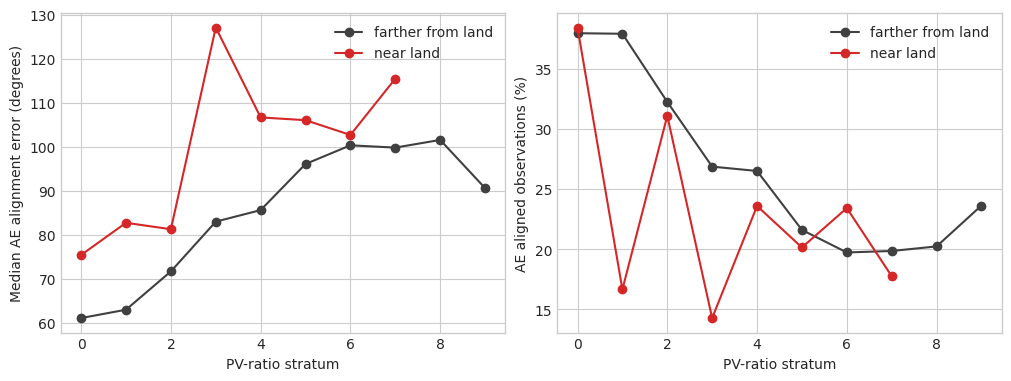

In [5]:
ae=use[use.Cyc=='AE'].copy()
ae['ratio_stratum']=pd.qcut(ae.log_topo_plan,10,duplicates='drop')
rows=[]
for cutoff in [25,50,100,150,200]:
 ae['near']=ae.coast_distance_km<=cutoff
 for (ratio_bin,near),part in ae.groupby(['ratio_stratum','near'],observed=True):
  rows.append({'cutoff_km':cutoff,'ratio_bin':ratio_bin,'near':near,
   'preference_error':part.preference_error.median(),
   'p_predicted':part.predicted_30.mean(),'tilt_km':part.TiltDis.median(),
   'observations':len(part),'eddies':part.Eddy.nunique()})
proximity=pd.DataFrame(rows)
display(proximity[proximity.eddies>=10].head(30))
fig,axs=plt.subplots(1,2,figsize=(10,3.7),constrained_layout=True)
for near,label,color in [(False,'farther from land','0.25'),(True,'near land','tab:red')]:
 part=proximity[(proximity.cutoff_km==100)&(proximity.near==near)&(proximity.eddies>=10)]
 x=np.arange(len(part));axs[0].plot(x,part.preference_error,'-o',color=color,label=label)
 axs[1].plot(x,100*part.p_predicted,'-o',color=color,label=label)
axs[0].set(xlabel='PV-ratio stratum',ylabel='Median AE alignment error (degrees)')
axs[1].set(xlabel='PV-ratio stratum',ylabel='AE aligned observations (%)')
for ax in axs: ax.legend(frameon=False)


## 5. Within-eddy shelf encounter

For every AE observed both near and far from land, compare the eddy with itself. A systematic near-minus-far increase in alignment error supports disruption. Evidence is stronger if tilt distance also changes.


,count,mean,std,min,25%,50%,75%,max
Eddy,124.0,1493.677419,860.740384,11.000000,745.000000,1536.000000,2167.000000,2971.000000
near_minus_far_error,124.0,4.947426,50.532264,-154.406259,-27.555138,3.842703,40.930215,148.994706
near_minus_far_tilt_km,124.0,5.292763,21.234213,-63.867179,-5.511932,3.419383,12.366876,74.432683
near_minus_far_log_ratio,124.0,0.715373,1.307984,-2.215468,-0.094414,0.441078,1.000724,4.571889
n_near,124.0,15.612903,10.882753,3.000000,7.000000,13.500000,21.000000,77.000000
n_far,124.0,30.637097,37.934332,3.000000,9.000000,16.000000,36.250000,268.000000


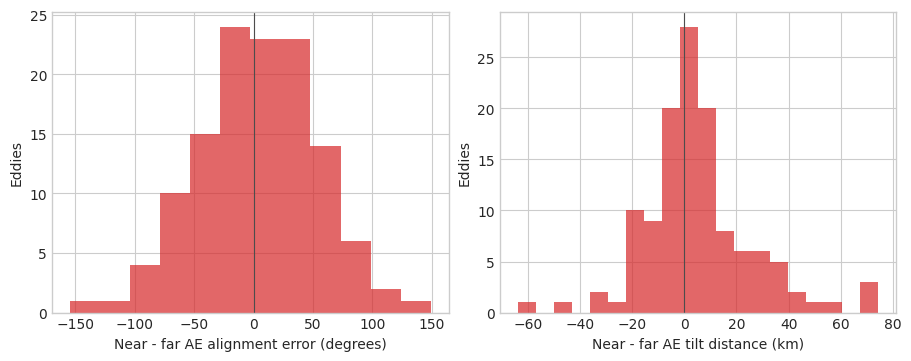

In [6]:
ae=use[use.Cyc=='AE'].copy();ae['near_100km']=ae.coast_distance_km<=100
rows=[]
for eddy,part in ae.groupby('Eddy'):
 if part.near_100km.nunique()<2: continue
 far=part[~part.near_100km];near=part[part.near_100km]
 if min(len(far),len(near))<3: continue
 rows.append({'Eddy':eddy,
  'near_minus_far_error':near.preference_error.median()-far.preference_error.median(),
  'near_minus_far_tilt_km':near.TiltDis.median()-far.TiltDis.median(),
  'near_minus_far_log_ratio':near.log_topo_plan.median()-far.log_topo_plan.median(),
  'n_near':len(near),'n_far':len(far)})
paired=pd.DataFrame(rows);display(paired.describe().T)
fig,axs=plt.subplots(1,2,figsize=(9,3.5),constrained_layout=True)
axs[0].hist(paired.near_minus_far_error,bins='fd',color='tab:red',alpha=.7)
axs[1].hist(paired.near_minus_far_tilt_km,bins='fd',color='tab:red',alpha=.7)
axs[0].set(xlabel='Near - far AE alignment error (degrees)',ylabel='Eddies')
axs[1].set(xlabel='Near - far AE tilt distance (km)',ylabel='Eddies')
for ax in axs: ax.axvline(0,color='0.3',lw=.8)


## 6. Evidence standard and formal model

Call this shelf cancellation only if: (1) AEs align in unconstrained planetary conditions; (2) alignment degrades with proximity after controlling for PV ratio, slope, depth, latitude and region; (3) the change recurs within tracks; and (4) tilt magnitude, along-shelf redirection, or propagation changes consistently.

If only the angle broadens, report **loss of directional coherence**, not mechanical cancellation. The formal follow-up should use a circular/cosine response with smooth PV-ratio and coast-distance effects, their interaction, and eddy/region grouping. An event study centred on first shelf encounter is stronger, particularly after adding translation velocity and a shelf-normal direction.
